# Análise exploratória de dados

## Problema gerador: *Titanic - mulheres e crianças primeiro? Jack e Rose existiram?*

#### Importando a biblioteca **Pandas**

In [1]:
import pandas as pd

#### carregando o dataset

 **na_values** - é passado por parâmetro uma string que o Pandas reconheça como dado NaN

In [2]:
df = pd.read_csv("titanic_completa_oficial.csv", na_values="?")

In [3]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


### Informações do dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


### Visão *percentual* dos **dados faltantes**

In [5]:
(df.isnull().sum()/df.shape[0])*100

pclass        0.000000
survived      0.000000
name          0.000000
sex           0.000000
age          20.091673
sibsp         0.000000
parch         0.000000
ticket        0.000000
fare          0.076394
cabin        77.463713
embarked      0.152788
boat         62.872422
body         90.756303
home.dest    43.086325
dtype: float64

#### Importando a biblioteca **NumPy**

In [6]:
import numpy as np

##### selecionando as colunas que possuem **dados categóricos**

In [7]:
df.select_dtypes(exclude=np.number)

,name,sex,ticket,cabin,embarked,boat,home.dest
0,"Allen, Miss. Elisabeth Walton",female,24160,B5,S,2,"St Louis, MO"
1,"Allison, Master. Hudson Trevor",male,113781,C22 C26,S,11,"Montreal, PQ / Chesterville, ON"
2,"Allison, Miss. Helen Loraine",female,113781,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"
3,"Allison, Mr. Hudson Joshua Creighton",male,113781,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,113781,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...
1304,"Zabour, Miss. Hileni",female,2665,NaN,C,NaN,NaN
1305,"Zabour, Miss. Thamine",female,2665,NaN,C,NaN,NaN
1306,"Zakarian, Mr. Mapriededer",male,2656,NaN,C,NaN,NaN
1307,"Zakarian, Mr. Ortin",male,2670,NaN,C,NaN,NaN


##### selecionando as colunas que possuem **dados numéricos**

In [8]:
df.select_dtypes(include=np.number)

,pclass,survived,age,sibsp,parch,fare,body
0,1,1,29.0000,0,0,211.3375,NaN
1,1,1,0.9167,1,2,151.5500,NaN
2,1,0,2.0000,1,2,151.5500,NaN
3,1,0,30.0000,1,2,151.5500,135.0
4,1,0,25.0000,1,2,151.5500,NaN
...,...,...,...,...,...,...,...
1304,3,0,14.5000,1,0,14.4542,328.0
1305,3,0,NaN,1,0,14.4542,NaN
1306,3,0,26.5000,0,0,7.2250,304.0
1307,3,0,27.0000,0,0,7.2250,NaN


### Analisando os dados
Perfil **demográfico** do Titanic (em termos de classe)

In [9]:
# quantas pessoas tem na base?
df.shape[0]

1309

In [10]:
# quais as classes?
df["pclass"].unique()

array([1, 2, 3], dtype=int64)

In [11]:
# quantas observações estão em cada classe?
(df["pclass"].value_counts(normalize=True))*100

pclass
3    54.163484
1    24.675325
2    21.161192
Name: proportion, dtype: float64

In [12]:
df.select_dtypes(include=np.number)

,pclass,survived,age,sibsp,parch,fare,body
0,1,1,29.0000,0,0,211.3375,NaN
1,1,1,0.9167,1,2,151.5500,NaN
2,1,0,2.0000,1,2,151.5500,NaN
3,1,0,30.0000,1,2,151.5500,135.0
4,1,0,25.0000,1,2,151.5500,NaN
...,...,...,...,...,...,...,...
1304,3,0,14.5000,1,0,14.4542,328.0
1305,3,0,NaN,1,0,14.4542,NaN
1306,3,0,26.5000,0,0,7.2250,304.0
1307,3,0,27.0000,0,0,7.2250,NaN


In [13]:
# qual a distribuição de sexo?
(df["sex"].value_counts(normalize=True))*100

sex
male      64.400306
female    35.599694
Name: proportion, dtype: float64

In [14]:
# qual a distribuição das variáveis numéricas?
df["fare"].describe()

count    1308.000000
mean       33.295479
std        51.758668
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: fare, dtype: float64

<Axes: ylabel='Frequency'>

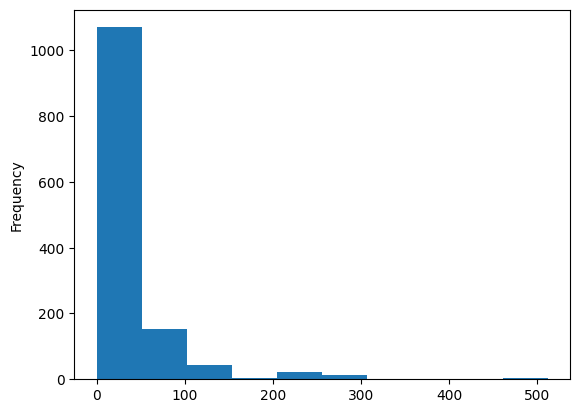

In [15]:
df["fare"].plot(kind="hist")

<Axes: ylabel='Density'>

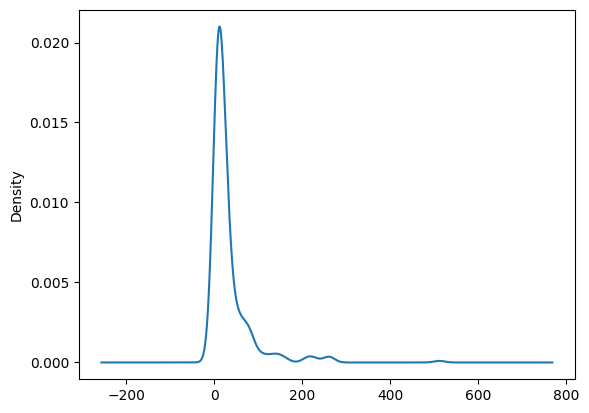

In [16]:
df["fare"].plot(kind="kde")

In [17]:
# qual a taxa de sobrevivência do titanic?
df["survived"].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [18]:
(df["survived"].value_counts(normalize=True))*100

survived
0    61.802903
1    38.197097
Name: proportion, dtype: float64

#### Pergunta: qual é a proporção de mulheres/homens que sobreviveram/morreram?

##### nota-se que mais de **80% de homens morreram** a bordo do titanic, e **19% sobreviveram**


In [19]:
(df.query("sex == 'male'")["survived"].value_counts(normalize=True))*100

survived
0    80.901542
1    19.098458
Name: proportion, dtype: float64

##### **27% de mulheres morreram** a bordo do titanic, e mais de **72% sobreviveram**

In [20]:
(df.query("sex == 'female'")["survived"].value_counts(normalize=True))*100

survived
1    72.746781
0    27.253219
Name: proportion, dtype: float64

#### Pergunta referente a anterior: e com relação as classes?

**Primeira classe**

In [21]:
# homens
(df.query("sex == 'male' and pclass == 1")["survived"].mean())*100

34.07821229050279

In [22]:
# mulheres 
(df.query("sex == 'female' and pclass == 1")["survived"].mean())*100

96.52777777777779

 **Segunda classe**

In [23]:
# homens
(df.query("sex == 'male' and pclass == 2")["survived"].mean())*100

14.619883040935672

In [24]:
# mulheres 
(df.query("sex == 'female' and pclass == 2")["survived"].mean())*100

88.67924528301887

 **Terceira classe**

In [25]:
# homens
(df.query("sex == 'male' and pclass == 3")["survived"].mean())*100

15.212981744421908

In [26]:
# mulheres 
(df.query("sex == 'female' and pclass == 3")["survived"].mean())*100

49.074074074074076

### Método **Groupby**


#### Útil para *agrupar* os dados

##### Pergunta: qual a relação entre o sexo, a taxa de sobrevivência, e a classe?

In [27]:
df.groupby(["pclass", "sex"])["survived"].mean()

pclass  sex   
1       female    0.965278
        male      0.340782
2       female    0.886792
        male      0.146199
3       female    0.490741
        male      0.152130
Name: survived, dtype: float64

In [28]:
(df.groupby(["pclass", "sex"])[["survived"]].mean())*100

survived
pclass sex              
1      female  96.527778
       male    34.078212
2      female  88.679245
       male    14.619883
3      female  49.074074
       male    15.212982

Método **agg()** permite várias agregações sendo passadas por parâmetro

In [29]:
(df.groupby(["pclass", "sex"])[["survived"]].agg(["mean", "std"]))*100

survived           
                    mean        std
pclass sex                         
1      female  96.527778  18.371437
       male    34.078212  47.530174
2      female  88.679245  31.835155
       male    14.619883  35.434305
3      female  49.074074  50.107550
       male    15.212982  35.951148

In [30]:
df.groupby(["pclass", "sex"])[["fare"]].agg(["mean","min", "max", "std"])

fare                            
                     mean    min       max        std
pclass sex                                           
1      female  109.412385  25.70  512.3292  82.885854
       male     69.888385   0.00  512.3292  74.079427
2      female   23.234827  10.50   65.0000  11.239817
       male     19.904946   0.00   73.5000  14.775149
3      female   15.324250   6.75   69.5500  11.786512
       male     12.415462   0.00   69.5500  11.261638

#### Pergunta: qual a relação entre o porto de embarque, a taxa de sobrevivência, e a classe?

In [31]:
df["embarked"].value_counts()

embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [32]:
df.groupby(["pclass", "embarked"])[["survived"]].agg(["mean","count"])

survived      
                     mean count
pclass embarked                
1      C         0.687943   141
       Q         0.666667     3
       S         0.559322   177
2      C         0.571429    28
       Q         0.285714     7
       S         0.417355   242
3      C         0.366337   101
       Q         0.353982   113
       S         0.210101   495

### Respondendo a pergunta: *Mulheres e crianças sobreviveram mais?*

In [33]:
# Quantas pessoas morreram? quantas sobreviveram?
df["survived"].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [34]:
# Qual a proporção de sobreviventes e mortos?
(df["survived"].value_counts(normalize=True))*100

survived
0    61.802903
1    38.197097
Name: proportion, dtype: float64

In [35]:
# Qual a quantidade de pessoas de cada sexo que morreu e sobreviveu?
(df.groupby("sex")["survived"].value_counts(normalize=True))*100

sex     survived
female  1           72.746781
        0           27.253219
male    0           80.901542
        1           19.098458
Name: proportion, dtype: float64

Modificação do groupby feito acima referente ao porto e classe incluindo também o **sexo** como agrupador


In [36]:
(df.groupby(["sex", "embarked", "pclass"])[["survived"]].mean())*100

survived
sex    embarked pclass            
female C        1        97.183099
                2       100.000000
                3        70.967742
       Q        1       100.000000
                2       100.000000
                3        58.928571
       S        1        95.652174
                2        87.096774
                3        39.534884
male   C        1        40.000000
                2        29.411765
                3        21.428571
       Q        1         0.000000
                2         0.000000
                3        12.280702
       S        1        30.555556
                2        13.422819
                3        14.480874

In [37]:
df.groupby(["sex", "embarked", "pclass"])[["survived"]].agg(["mean", "count"])

survived      
                            mean count
sex    embarked pclass                
female C        1       0.971831    71
                2       1.000000    11
                3       0.709677    31
       Q        1       1.000000     2
                2       1.000000     2
                3       0.589286    56
       S        1       0.956522    69
                2       0.870968    93
                3       0.395349   129
male   C        1       0.400000    70
                2       0.294118    17
                3       0.214286    70
       Q        1       0.000000     1
                2       0.000000     5
                3       0.122807    57
       S        1       0.305556   108
                2       0.134228   149
                3       0.144809   366

Agrupando por *porto*, *classe*, *sexo* e *survived*, e pegando as contagens de **"survived"**

In [38]:
df.groupby(["sex", "embarked", "pclass", "survived"])[["survived"]].agg(["count"])

survived
                                   count
sex    embarked pclass survived         
female C        1      0               2
                       1              69
                2      1              11
                3      0               9
                       1              22
       Q        1      1               2
                2      1               2
                3      0              23
                       1              33
       S        1      0               3
                       1              66
                2      0              12
                       1              81
                3      0              78
                       1              51
male   C        1      0              42
                       1              28
                2      0              12
                       1               5
                3      0              55
                       1              15
       Q        1      0               1
                2      0               5
                3      0              50
                       1               7
       S        1      0              75
                       1              33
                2      0             129
                       1              20
                3      0             313
                       1              53

Incluindo a **idade** na análise

In [39]:
# Média de idade dos passageiros olhando para a classe e o sexo.
df.groupby(["sex", "pclass"])[["age"]].agg(["mean","count"])

age      
                    mean count
sex    pclass                 
female 1       37.037594   133
       2       27.499191   103
       3       22.185307   152
male   1       41.029250   151
       2       30.815401   158
       3       25.962273   349

In [40]:
# Média de idade dos passageiros que sobreviveram/morreram olhando para a classe e o sexo
df.groupby([ "survived","sex", "pclass"])[["age"]].agg(["mean", "count"])

age      
                             mean count
survived sex    pclass                 
0        female 1       35.200000     5
                2       34.090909    11
                3       23.418750    80
         male   1       43.658163    98
                2       33.092593   135
                3       26.679598   290
1        female 1       37.109375   128
                2       26.711051    92
                3       20.814815    72
         male   1       36.168240    53
                2       17.449274    23
                3       22.436441    59

### Método **apply()**
#### Permite a *modificação* ou *criação* de colunas a partir de colunas já existentes

In [41]:
idade = 20

def calc_faixa_etaria(idade):
    
    if np.isnan(idade):
        return "desconhecida"
    elif idade <= 15:
        return "0-15"
    elif idade <= 30:
        return "15-30"
    elif idade <= 45:
        return "30-45"
    else:
        return "45+"

In [42]:
df["age"]

0       29.0000
1        0.9167
2        2.0000
3       30.0000
4       25.0000
         ...   
1304    14.5000
1305        NaN
1306    26.5000
1307    27.0000
1308    29.0000
Name: age, Length: 1309, dtype: float64

 #### Coluna *age_group* criada contendo a **faixa etária** de cada passageiro *(0-15, 15-30, 30-45, 45+)*

In [43]:
df["age_group"]= df["age"].apply(calc_faixa_etaria)

In [44]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,age_group
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",15-30
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",0-15
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0-15
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",15-30
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",15-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,0-15
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,desconhecida
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,15-30
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,15-30


In [45]:
df["age_group"].value_counts()

age_group
15-30           494
30-45           282
desconhecida    263
45+             155
0-15            115
Name: count, dtype: int64

### Respondendo perguntas referente a coluna **age_group**

In [46]:
# qual a distribuição de sexo em cada faixa etária?
df.groupby(["age_group", "sex"])[["sex"]].count()

sex
age_group    sex        
0-15         female   56
             male     59
15-30        female  179
             male    315
30-45        female  101
             male    181
45+          female   52
             male    103
desconhecida female   78
             male    185

In [47]:
# qual a proporção de mortes/sobrevivência dentro de cada faixa etária?
df.groupby("age_group")[["survived"]].agg(["mean", "count"])

survived      
                  mean count
age_group                   
0-15          0.573913   115
15-30         0.368421   494
30-45         0.414894   282
45+           0.400000   155
desconhecida  0.277567   263

Analisando a taxa de sobrevivência por sexo e faixa etária

In [48]:
df.groupby(["age_group", "sex"])[["survived"]].agg(["mean", "count"])

survived      
                         mean count
age_group    sex                   
0-15         female  0.660714    56
             male    0.491525    59
15-30        female  0.720670   179
             male    0.168254   315
30-45        female  0.792079   101
             male    0.204420   181
45+          female  0.884615    52
             male    0.155340   103
desconhecida female  0.602564    78
             male    0.140541   185

### Respondendo a pergunta: *Jack e Rose existiram?*

A estrutura dos nomes é: 
##### Sobrenome, Título. Primeiro Nome

In [49]:
df["name"]

0                         Allen, Miss. Elisabeth Walton
1                        Allison, Master. Hudson Trevor
2                          Allison, Miss. Helen Loraine
3                  Allison, Mr. Hudson Joshua Creighton
4       Allison, Mrs. Hudson J C (Bessie Waldo Daniels)
                             ...                       
1304                               Zabour, Miss. Hileni
1305                              Zabour, Miss. Thamine
1306                          Zakarian, Mr. Mapriededer
1307                                Zakarian, Mr. Ortin
1308                                 Zimmerman, Mr. Leo
Name: name, Length: 1309, dtype: object

In [50]:
string = "Sobrenome, Título. Primeiro Nome"

Pegando o Sobrenome e o Título com a função **split**

In [51]:
string.split(",")[0]

'Sobrenome'

In [52]:
string.split(",")[1].split(".")[0]

' Título'

Coluna criada com o método **apply()** contendo os sobrenomes 

In [53]:
def extrai_sobrenome(s):
    
     return s.split(",")[0]

In [54]:
df["surname"] = df["name"].apply(extrai_sobrenome)

In [55]:
df["surname"]

0           Allen
1         Allison
2         Allison
3         Allison
4         Allison
          ...    
1304       Zabour
1305       Zabour
1306     Zakarian
1307     Zakarian
1308    Zimmerman
Name: surname, Length: 1309, dtype: object

Coluna criada com o método **apply()** contendo os títulos

In [56]:
def extrai_titulo(t):
    
    return t.split(",")[1].split(".")[0]

In [57]:
df["title"] = df["name"].apply(extrai_titulo)

In [58]:
df["title"]

0          Miss
1        Master
2          Miss
3            Mr
4           Mrs
         ...   
1304       Miss
1305       Miss
1306         Mr
1307         Mr
1308         Mr
Name: title, Length: 1309, dtype: object

Outra forma de criar a coluna de títulos com o **apply()** e função **lambda**

In [61]:
df["name"].apply(lambda x: x.split(",")[1].split(".")[0])

0          Miss
1        Master
2          Miss
3            Mr
4           Mrs
         ...   
1304       Miss
1305       Miss
1306         Mr
1307         Mr
1308         Mr
Name: name, Length: 1309, dtype: object

In [62]:
df[["surname", "title"]]

,surname,title
0,Allen,Miss
1,Allison,Master
2,Allison,Miss
3,Allison,Mr
4,Allison,Mrs
...,...,...
1304,Zabour,Miss
1305,Zabour,Miss
1306,Zakarian,Mr
1307,Zakarian,Mr


### Com base na exploração dos dados é concluido que *Jack e Rose* **não** existiram no Titanic

In [68]:
df[df["name"].apply(lambda x: "Rose" in x)]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,age_group,surname,title
242,1,1,"Rosenbaum, Miss. Edith Louise",female,33.0,0,0,PC 17613,27.7208,A11,C,11,NaN,"Paris, France",30-45,Rosenbaum,Miss
243,1,0,"Rosenshine, Mr. George ('Mr George Thorne')",male,46.0,0,0,PC 17585,79.2000,NaN,C,NaN,16.0,"New York, NY",45+,Rosenshine,Mr
612,3,1,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,13,NaN,"London, England Norfolk, VA",15-30,Aks,Mrs


In [69]:
df[df["name"].apply(lambda x: "Jack" in x)]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,age_group,surname,title
40,1,0,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6,NaN,C,NaN,NaN,"Philadelphia, PA",desconhecida,Brewe,Dr


##### Salvando o dataframe

In [70]:
df.to_csv("titanic_processado.csv", index=False)